# Self-Attention, Multi-Head Attention, and Positional Encoding

Attention originally allows one representation to focus on another set of sequence states. Self-attention applies the same idea **within one sequence**.

Every token can directly examine the other tokens and decide which positions are relevant to its new representation.

The learning progression is:

```text
attention
→ self-attention
→ scaled dot-product attention
→ padding and causal masks
→ multi-head attention
→ positional encoding
```


## From Attention to Self-Attention


In self-attention, Query, Key, and Value all come from the same input sequence.

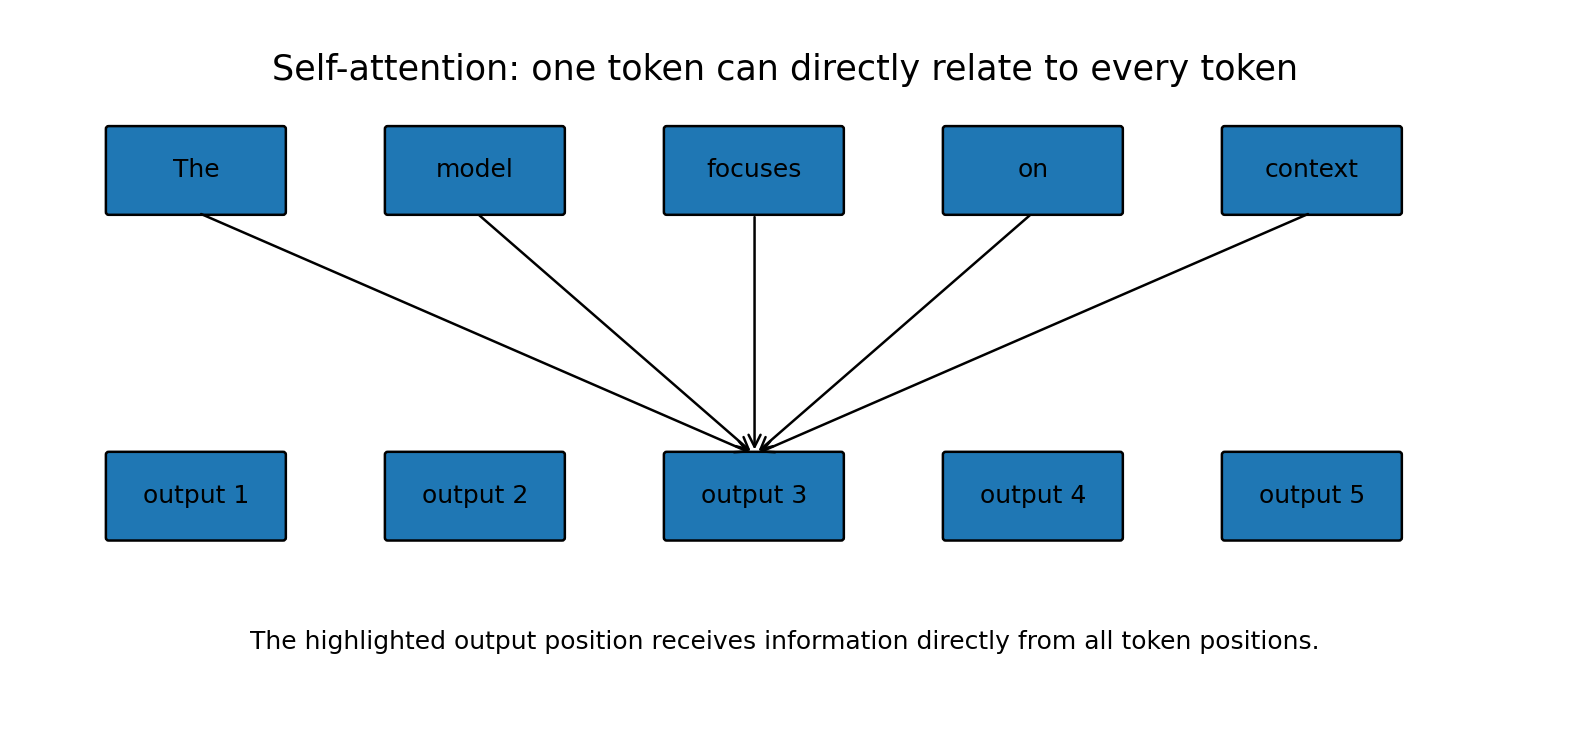

This creates a direct interaction path between sequence positions. A token does not have to wait for information to pass through many recurrent time steps.


## Import Libraries


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)


## A Small Token-Embedding Sequence


In [2]:
X = tf.constant([
    [1.0,0.0,1.0,0.0],
    [0.0,1.0,1.0,0.0],
    [1.0,1.0,0.0,0.0],
    [0.0,0.0,1.0,1.0]
],dtype=tf.float32)

print('Sequence shape:',X.shape)
print(X.numpy())


Sequence shape: (4, 4)
[[1. 0. 1. 0.]
 [0. 1. 1. 0.]
 [1. 1. 0. 0.]
 [0. 0. 1. 1.]]


Each row is one token embedding. For demonstration, the embedding dimension is 4.


## Learnable Query, Key, and Value Projections


In [3]:
d_model = 4

Wq = tf.Variable(tf.random.normal((d_model,d_model),stddev=0.2))
Wk = tf.Variable(tf.random.normal((d_model,d_model),stddev=0.2))
Wv = tf.Variable(tf.random.normal((d_model,d_model),stddev=0.2))

Q = X @ Wq
K = X @ Wk
V = X @ Wv

print('Q shape:',Q.shape)
print('K shape:',K.shape)
print('V shape:',V.shape)


Q shape: (4, 4)
K shape: (4, 4)
V shape: (4, 4)


The projection matrices `Wq`, `Wk`, and `Wv` are learned parameters in a trained attention layer.


## Scaled Dot-Product Self-Attention


In [4]:
def scaled_dot_product_attention(Q,K,V,mask=None):
    dk = tf.cast(tf.shape(K)[-1],tf.float32)
    scores = tf.matmul(Q,K,transpose_b=True)/tf.math.sqrt(dk)

    if mask is not None:
        scores += mask*-1e9

    weights = tf.nn.softmax(scores,axis=-1)
    output = tf.matmul(weights,V)
    return output,weights

attention_output,attention_weights = scaled_dot_product_attention(Q,K,V)

print('Attention output shape:',attention_output.shape)
print('Attention weights shape:',attention_weights.shape)
print('\nAttention weights:')
print(attention_weights.numpy())


Attention output shape: (4, 4)
Attention weights shape: (4, 4)

Attention weights:
[[0.25625965 0.25040004 0.2385202  0.2548201 ]
 [0.24930152 0.25308597 0.23094806 0.26666445]
 [0.25319505 0.24608159 0.23197024 0.2687531 ]
 [0.25384042 0.24616428 0.22684263 0.27315268]]


## Visualize the Self-Attention Matrix


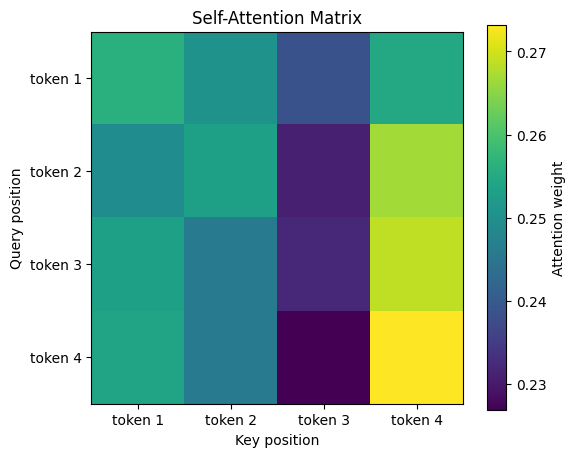

In [5]:
plt.figure(figsize=(6,5))
plt.imshow(attention_weights.numpy())
plt.colorbar(label='Attention weight')
plt.xlabel('Key position')
plt.ylabel('Query position')
plt.title('Self-Attention Matrix')
plt.xticks(range(4),['token 1','token 2','token 3','token 4'])
plt.yticks(range(4),['token 1','token 2','token 3','token 4'])
plt.show()


Each row is one query position. Each column is one key position.

A large value in row 2, column 4 means that token 2 gives relatively high attention to token 4.


## Padding Mask


Padding tokens should not contribute to the representation. A padding mask prevents attention from assigning weight to padded positions.


In [6]:
padding_mask = tf.constant([
    [0.0,0.0,0.0,1.0],
    [0.0,0.0,0.0,1.0],
    [0.0,0.0,0.0,1.0],
    [0.0,0.0,0.0,1.0]
],dtype=tf.float32)

masked_output,masked_weights = scaled_dot_product_attention(Q,K,V,padding_mask)

print(masked_weights.numpy())


[[0.34388962 0.33602628 0.32008404 0.        ]
 [0.33995557 0.3451162  0.31492823 0.        ]
 [0.34625113 0.3365233  0.3172256  0.        ]
 [0.34923485 0.33867395 0.31209117 0.        ]]


## Causal Mask


For next-token prediction, a token must not look at future tokens.

A causal mask allows position $t$ to attend only to positions at or before $t$.


In [7]:
seq_len = X.shape[0]
causal_mask = 1-tf.linalg.band_part(tf.ones((seq_len,seq_len)),-1,0)

causal_output,causal_weights = scaled_dot_product_attention(Q,K,V,causal_mask)

print('Causal mask:')
print(causal_mask.numpy())
print('\nCausal attention weights:')
print(causal_weights.numpy())


Causal mask:
[[0. 1. 1. 1.]
 [0. 0. 1. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 0.]]

Causal attention weights:
[[1.         0.         0.         0.        ]
 [0.49623352 0.5037665  0.         0.        ]
 [0.34625113 0.3365233  0.3172256  0.        ]
 [0.25384042 0.24616428 0.22684263 0.27315268]]


## Visualize Causal Attention


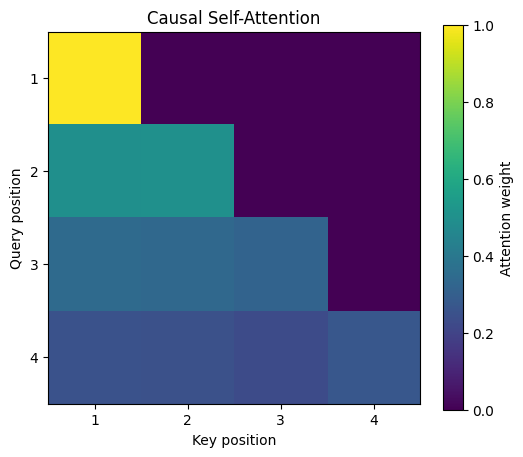

In [8]:
plt.figure(figsize=(6,5))
plt.imshow(causal_weights.numpy())
plt.colorbar(label='Attention weight')
plt.xlabel('Key position')
plt.ylabel('Query position')
plt.title('Causal Self-Attention')
plt.xticks(range(4),['1','2','3','4'])
plt.yticks(range(4),['1','2','3','4'])
plt.show()


## Multi-Head Attention


One attention head produces one pattern of relationships. Multi-head attention learns several sets of Query, Key, and Value projections in parallel.

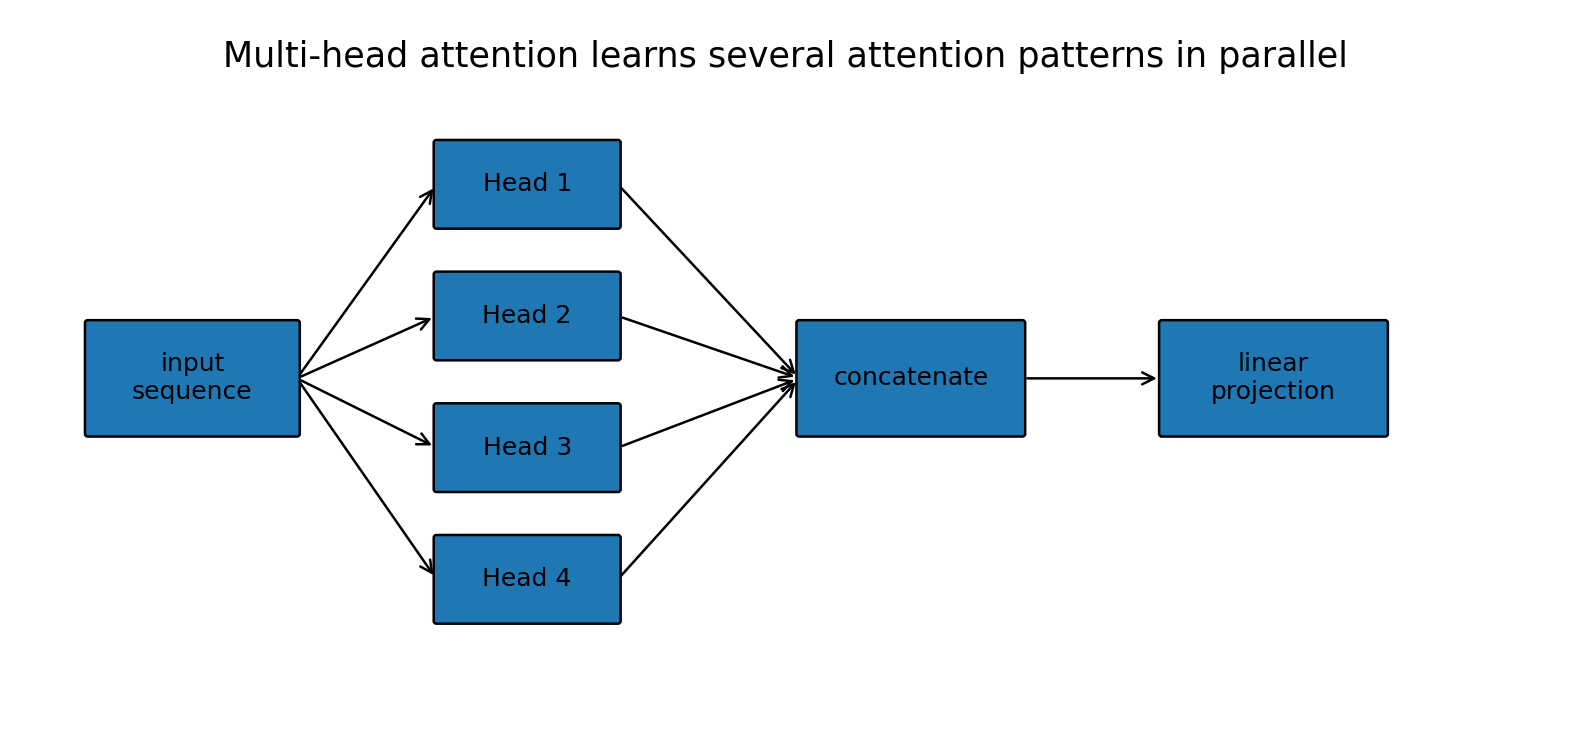

Different heads can learn different kinds of relationships. For text, one head might focus on nearby phrase structure while another focuses on longer-range relationships.


In [9]:
sequence = tf.expand_dims(X,axis=0)

mha = layers.MultiHeadAttention(num_heads=2,key_dim=2)
mha_output,mha_scores = mha(sequence,sequence,return_attention_scores=True)

print('Input shape:',sequence.shape)
print('Output shape:',mha_output.shape)
print('Attention score shape:',mha_scores.shape)


Input shape: (1, 4, 4)
Output shape: (1, 4, 4)
Attention score shape: (1, 2, 4, 4)


For this example:

```text
batch size = 1
number of heads = 2
query length = 4
key length = 4
```

so the attention-score tensor has shape `(1,2,4,4)`.


## Visualize One Attention Head


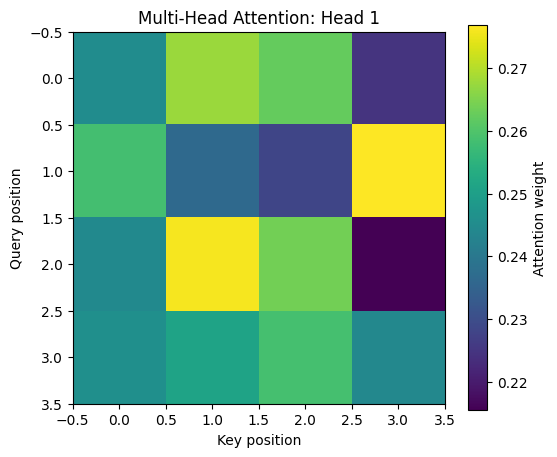

In [10]:
head_1 = mha_scores[0,0].numpy()

plt.figure(figsize=(6,5))
plt.imshow(head_1)
plt.colorbar(label='Attention weight')
plt.xlabel('Key position')
plt.ylabel('Query position')
plt.title('Multi-Head Attention: Head 1')
plt.show()


## Why Positional Information Is Needed


Self-attention directly compares token representations, but the attention calculation itself does not contain a recurrent time step.

Transformers therefore add position information to token embeddings so that the model can distinguish:

```text
dog bites man
```

from:

```text
man bites dog
```

One common approach is sinusoidal positional encoding.


## Sinusoidal Positional Encoding


In [11]:
def positional_encoding(length,d_model):
    positions = np.arange(length)[:,None]
    dimensions = np.arange(d_model)[None,:]
    angle_rates = 1/np.power(10000,(2*(dimensions//2))/np.float32(d_model))
    angles = positions*angle_rates

    encoding = np.zeros((length,d_model),dtype=np.float32)
    encoding[:,0::2] = np.sin(angles[:,0::2])
    encoding[:,1::2] = np.cos(angles[:,1::2])
    return encoding

pos_encoding = positional_encoding(50,32)

print('Positional encoding shape:',pos_encoding.shape)


Positional encoding shape: (50, 32)


## Visualize Positional Encoding


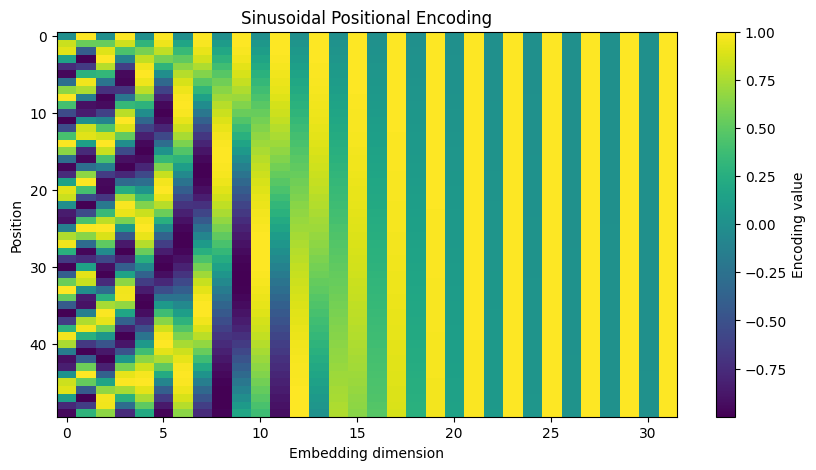

In [12]:
plt.figure(figsize=(10,5))
plt.imshow(pos_encoding,aspect='auto')
plt.colorbar(label='Encoding value')
plt.xlabel('Embedding dimension')
plt.ylabel('Position')
plt.title('Sinusoidal Positional Encoding')
plt.show()


## Self-Attention Compared with Recurrent Processing


The main architectural difference is the path information follows.

```text
RNN / LSTM / GRU
token 1 → hidden state → token 2 → hidden state → token 3 → ...

Self-attention
token 1 ↔ token 2 ↔ token 3 ↔ ... ↔ token n
```

Recurrent models have an explicit sequential state. Self-attention instead creates direct interactions between positions and can compute those interactions in parallel.

The tradeoff is that standard self-attention builds an $n \times n$ attention matrix, so its memory and compute cost grows quadratically with sequence length.


## Key Takeaways


- Self-attention uses Query, Key, and Value from the same sequence.
- Every token can directly interact with every other token.
- Padding masks remove padded positions from attention.
- Causal masks prevent a decoder from seeing future tokens.
- Multi-head attention learns several attention patterns in parallel.
- Positional encoding provides sequence-order information.
- Self-attention removes recurrence, but standard attention has quadratic sequence-length cost.
